**Testing MobileNetV3**

[group/personal details]

**Imports**

In [1]:
import torch
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import optim

*Setting manual Seed*

In [2]:
#Manual seed to create reproducibility (will have different seeds for the five runs with each loss function, but the same seeds across functions)
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    #random.seed(seed) include these if we are using random and np packages
    #np.random.seed(seed)



**Data & Data Loaders**

ciFAIR and CIFAR have the same training data (identical), but ciFAIR has different test data. As such, train data is from CIFAR10

In [3]:
cifar_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR_train_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,  
    download=True, 
    transform=cifar_transforms
)

no_train_classes = len(CIFAR_train_data.classes)
print(no_train_classes)

# Load the test data
# TODO decide on whether it is the ciFAR or CIFAR dataset
CIFAR_test_data = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,  
    download=True, 
    transform=cifar_transforms
)
no_test_classes = len(CIFAR_test_data.classes)
print(no_test_classes)

/home/ryan_guo/miniconda3/envs/ml_env/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


10
10


**Creating balanced and Imbalanced datasets**

This code was created with the help of chatGPT

In [4]:
import random
from torch.utils.data import Subset
#This version creates a smaller imabalanced dataset (total training set size is smaller than balnced version)
def make_imbalanced(dataset, imbalance_ratio, seed):
    class_indices = {i: [] for i in range(10)}
    
    for idx, (_, label) in enumerate(dataset):
        class_indices[label].append(idx)

    new_indices = []

    for cls, indices in class_indices.items():
        if cls < 3:
            keep = int(len(indices) * imbalance_ratio)
        else:
            keep = len(indices)

        new_indices.extend(indices[:keep])

    rng = random.Random(seed)
    rng.shuffle(new_indices)

    return Subset(dataset, new_indices)

# This imbalanced dataset has 10% of the images for classes 0-2 and 100% for 3-9

balanced_train = CIFAR_train_data



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6967788].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5161401..1.8112855].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.36201733..1.82].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42195398..1.4446442].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7589979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47408962..1.6544228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.490453..1.

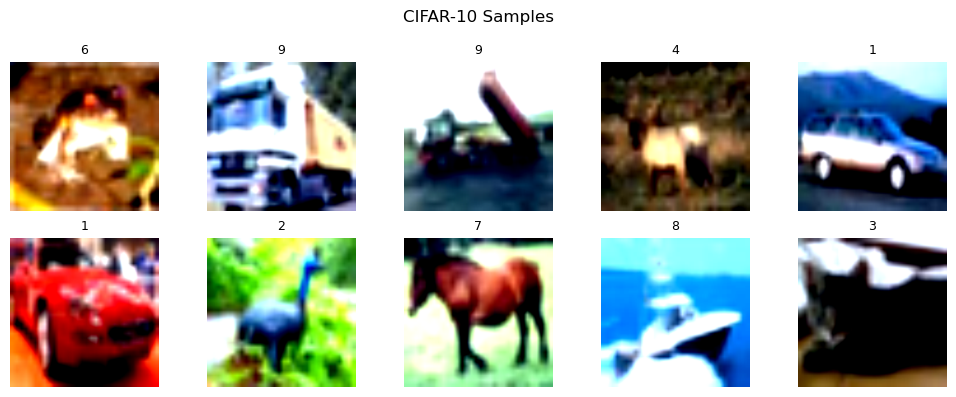

In [5]:
# code copied from lab 4, just for visualisation

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = CIFAR_train_data[i]
    img = img / 2 + 0.5
    ax.imshow(torch.permute(img, (1, 2, 0)))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 Samples')
plt.tight_layout()
plt.show()

In [6]:
# Setting up data loaders
def get_data_loaders(imbalanced, seed, imbalance_ratio, batch_size=64):
    # training_dataloader = DataLoader(CIFAR_train_data, batch_size=batch_size, shuffle=shuffle)
    training_dataloader = 0 # just initialising it
    if not imbalanced:
        training_dataloader = DataLoader(balanced_train, batch_size=batch_size,shuffle=False)
    else:
        imbalanced_train = make_imbalanced(CIFAR_train_data, imbalance_ratio, seed)
        training_dataloader = DataLoader(imbalanced_train, batch_size=batch_size,shuffle=False)
    test_dataloader = DataLoader(CIFAR_test_data, batch_size=batch_size, shuffle=False)

    return training_dataloader, test_dataloader

**MobileNetV3**

In [7]:
# Setting up model

def get_mobile_net_model(in_features=224, out_features=10):

    # in_features is number of in features, need modification to our dataset 
    # out_features is number of out features (i.e., classes), need modifcation to our data

    mobilenet_v3_small = models.mobilenet_v3_small(weights = None)
    mobilenet_v3_small.classifier[3] = nn.Linear(in_features=mobilenet_v3_small.classifier[3].in_features, out_features=out_features)

    print(mobilenet_v3_small.classifier)

    return mobilenet_v3_small

In [8]:
# Setting up optimiser for model

# TODO: justify the use of AdamW over SGD?
def get_optimiser_for_model(model):
    return torch.optim.AdamW(params=model.parameters(),lr=1e-3, weight_decay=1e-2)

**Training**

### How to Run Experiments ###

Each time set seed and imbalanced to what you want. Comment out loss functions you don't want to run.



In [ ]:
# TBD. Add loss functions in their section or their own.
import loss
import util
import pandas as pd
import importlib
from pathlib import Path

def get_training_data_path(balanced: bool, loss: str, seed: int):
    return Path("80epochs_training_data/" + ("balanced" if balanced else "imbalanced") + "/" + loss + "/" + "seed_" + str(seed))

def get_samples_per_class_and_class_weights(training_loader, no_train_classes):
    # get the samples_per_class
    samples_per_class = torch.zeros(no_train_classes, dtype=torch.long)
    for batch in training_loader:
        # Common case: batch = (inputs, labels)
        _, labels = batch

        # If labels are one-hot encoded, convert to class indices
        if labels.ndim > 1:
            labels = labels.argmax(dim=1)

        counts = torch.bincount(labels.cpu(), minlength=no_train_classes)
        samples_per_class += counts
        
    class_weights = 1.0 / samples_per_class.float()
    class_weights = class_weights / class_weights.sum() * len(class_weights)
    print(f"samples_per_class: {samples_per_class}")

    return samples_per_class, class_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 20
batches_to_train_with = float("inf")
seeds = [45, 2, 255, 18, 33]

# Remember to set this seed!
seed = seeds[0]
set_seed(seed)

# TODO change this variable for imbalanced or balanced data
imbalanced = True
imbalance_ratio = 0.1
training_loader,testing_loader = get_data_loaders(imbalanced, seed, imbalance_ratio)
samples_per_class, class_weights = get_samples_per_class_and_class_weights(training_loader=training_loader, no_train_classes=no_train_classes)

ce = loss.CrossEntropyLoss()
weighted_ce = loss.WeightedCrossEntropyLoss(class_weights=class_weights)
label_smoothing_ce = loss.LabelSmoothingCrossEntropyLoss(smoothing=0.1)
focal_loss = loss.FocalLoss(gamma=2.0, alpha=None)
class_balanced_loss = loss.ClassBalancedLoss(samples_per_class=samples_per_class, beta=0.9999)


# TODO comment out the ones you aren't running
# note that we are *not* running weighted_ce and class_balanced_loss for balanced
criterions = {
    "ce": ce,
    "weighted_ce": weighted_ce,
    "label_smoothing_ce": label_smoothing_ce,
    "focal_loss": focal_loss,
    "class_balanced_loss": class_balanced_loss
    }

all_training_losses = []
all_training_conf_matrices = []
all_testing_conf_matrices = []
all_accuracies = []
all_test_logits = []

# Main training loop
for criterion_name, criterion in criterions.items():
    all_training_losses = []
    all_training_conf_matrices = []
    all_testing_conf_matrices = []
    all_accuracies = []
    all_test_logits = []

    model = get_mobile_net_model().to(device)
    optimizer = get_optimiser_for_model(model)
    criterion = criterion.to(device)

    num_classes = no_train_classes

    for epoch in range(epochs):
        model.train()
        epoch_training_loss = 0.0
        trained_batches = 0
        train_conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)
        for data,labels in training_loader:
            data = data.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(data)
            loss_value = criterion(outputs, labels)
            
            loss_value.backward()
            optimizer.step()

            epoch_training_loss += loss_value.item()
            trained_batches += 1

            train_conf_matrix = util.update_confusion_matrix(
                train_conf_matrix,
                outputs.detach().cpu(),
                labels.detach().cpu()
            )

            if trained_batches >= batches_to_train_with:
                break
        avg_training_loss = epoch_training_loss / trained_batches

        model.eval()
        test_conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

        with torch.no_grad():
            for batch_idx, (data, labels) in enumerate(testing_loader):
                data = data.to(device)
                labels = labels.to(device)

                logits = model(data)

                test_conf_matrix = util.update_confusion_matrix(
                    test_conf_matrix,
                    logits.detach().cpu(),
                    labels.detach().cpu()
                )

                for sample_idx in range(logits.shape[0]):
                    row = {
                        "criterion": criterion_name,
                        "epoch": epoch + 1,
                        "batch_idx": batch_idx,
                        "sample_idx": sample_idx,
                        "true_label": labels[sample_idx].detach().cpu().item(),
                    }

                    for class_idx in range(num_classes):
                        row[f"logit_class_{class_idx}"] = logits[sample_idx, class_idx].detach().cpu().item()

                    all_test_logits.append(row)

        train_correct = train_conf_matrix.diag().sum().item()
        train_total = train_conf_matrix.sum().item()
        train_accuracy = train_correct / train_total if train_total > 0 else 0.0

        test_correct = test_conf_matrix.diag().sum().item()
        test_total = test_conf_matrix.sum().item()
        test_accuracy = test_correct / test_total if test_total > 0 else 0.0

        all_accuracies.append({
            "criterion": criterion_name,
            "epoch": epoch + 1,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy
        })
        
        all_training_losses.append({
            "criterion": criterion_name,
            "epoch": epoch + 1,
            "training_loss": avg_training_loss
        })

        for true_class in range(num_classes):
            for predicted_class in range(num_classes):
                all_training_conf_matrices.append({
                    "criterion": criterion_name,
                    "epoch": epoch + 1,
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": train_conf_matrix[true_class, predicted_class].item()
                })

                all_testing_conf_matrices.append({
                    "criterion": criterion_name,
                    "epoch": epoch + 1,
                    "true_class": true_class,
                    "predicted_class": predicted_class,
                    "count": test_conf_matrix[true_class, predicted_class].item()
                })


        print(
            f"Criterion: {criterion_name}, "
            f"Epoch: {epoch + 1}/{epochs}, "
            f"Training loss: {avg_training_loss:.4f},"
            f"Test accuracy: {test_accuracy}"
        )

    model.eval()
    eval_confusion_matrix = util.evaluate_model(
        model,
        testing_loader,
        no_test_classes,
        device
    )

    training_data_directory = get_training_data_path(
        not imbalanced, criterion_name, seed
    )
    training_data_directory.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(all_training_losses).to_csv(
        training_data_directory / "training_losses.csv",
        index=False
    )

    pd.DataFrame(all_training_conf_matrices).to_csv(
        training_data_directory / "training_confusion_matrices.csv",
        index=False
    )

    pd.DataFrame(all_testing_conf_matrices).to_csv(
        training_data_directory / "testing_confusion_matrices.csv",
        index=False
    )

    pd.DataFrame(all_accuracies).to_csv(
        training_data_directory / "accuracies.csv",
        index=False
    )

    pd.DataFrame(all_test_logits).to_csv(
        training_data_directory / "test_logits.csv",
        index=False
    )

    pd.DataFrame(eval_confusion_matrix).to_csv(
        training_data_directory / "eval_confusion_matrix.csv",
        index=False
    )

    print(f"\nTraining complete for criterion: {criterion_name}, seed: {seed}")
    print(f"Results saved to: {training_data_directory.resolve()}")

samples_per_class: tensor([ 500,  500,  500, 5000, 5000, 5000, 5000, 5000, 5000, 5000])


/mnt/d/comp_courses/comp3242/Project/Testing-MobileNet/loss.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_weights = torch.tensor(class_weights, dtype=torch.float32)
/mnt/d/comp_courses/comp3242/Project/Testing-MobileNet/loss.py:142: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  samples_per_class = torch.tensor(samples_per_class, dtype=torch.float32)


Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=10, bias=True)
)
Criterion: focal_loss, Epoch: 1/80, Training loss: 0.8064,Test accuracy: 0.3325
Criterion: focal_loss, Epoch: 2/80, Training loss: 0.5226,Test accuracy: 0.5582
Criterion: focal_loss, Epoch: 3/80, Training loss: 0.4043,Test accuracy: 0.6158
Criterion: focal_loss, Epoch: 4/80, Training loss: 0.3277,Test accuracy: 0.6427
Criterion: focal_loss, Epoch: 5/80, Training loss: 0.2644,Test accuracy: 0.664
Criterion: focal_loss, Epoch: 6/80, Training loss: 0.2181,Test accuracy: 0.6727
Criterion: focal_loss, Epoch: 7/80, Training loss: 0.1798,Test accuracy: 0.6532
Criterion: focal_loss, Epoch: 8/80, Training loss: 0.1520,Test accuracy: 0.6474
Criterion: focal_loss, Epoch: 9/80, Training loss: 0.1257,Test accuracy: 0.6624
Criterion: focal_loss, Epoch: 10/80, Training loss: 0.1075,Test accuracy: 0.6517
Criterion:

**Evaluation**

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

**Misc.**